# A3: Predicting Car Price (Classification Report)

**Student:** Jarin Tasnim Rodoshi (st126736)  
**Course:** AT82.03 Machine Learning  
**Assignment:** A3: Predicting Car Price (Classification)

---

## Summary

In A1 and A2 the Cars dataset was a regression problem. In A3 it is a **4-class classification problem**: the selling price is cut into four ordered price ranges (Budget, Affordable, Premium, Luxury), and a multinomial logistic regression written from scratch predicts the range from brand, year, fuel, max power and mileage.

| Task | What was done |
|---|---|
| **Task 1** | Added `accuracy`, per-class `precision` / `recall` / `f1`, `macro_*`, `weighted_*` and `support` to the `LogisticRegression` class. Verified against `sklearn.metrics.classification_report`. |
| **Task 2** | Added an optional Ridge (L2) penalty: `use_penalty=True, lambda_=...`. |
| **Task 3** | 16-configuration sweep tracked with MLflow (local instance); best model registered as `st126736-a3-model` (alias `staging`); Flask app served through Docker; two unit tests; a GitHub Actions pipeline that tests every push to `main` and, if the tests pass, builds and pushes the Docker image and deploys it to the course VM (§5.3 and §6.2). |

**Headline result.** Best model: `minibatch-lr0.1-noPenalty`, chosen on the **validation** set.

| Metric | Validation | Test |
|---|---|---|
| Accuracy | 0.8436 | **0.8481** |
| Macro F1 | 0.8245 | 0.8402 |
| Weighted F1 | **0.8418** | 0.8473 |


 **Note on the MLflow server.** The course MLflow server was unstable during this assignment. Per the TA's announcement, Objectives 1 and 2 were completed on a **local MLflow instance** (SQLite, `mlflow.db`) and the required screenshots of the runs and the registered model are included in Section 4. Objective 3 (CI/CD) is unchanged and is documented in §5.3 and §6.

---

## Repository layout
```bash
A3-Predicting-Car-Price/
├── .github/
│   └── workflows/
│       └── ci-cd.yml                  # CI (tests) + CD (build, push, deploy)
├── app/
│   ├── app.py
│   ├── logistic_regression.py
│   ├── mlflow_wrapper.py
│   ├── Model/
│   │   ├── model.pkl
│   │   └── preprocess.pkl
│   ├── static/
│   │   └── style.css
│   ├── templates/
│   │   └── index.html
│   └── tests/
│       └── test_model.py
├── docs/
│   ├── flask_local.png
│   ├── docker_localhost.png
│   ├── deployed_app.png
│   ├── ci_green.png
│   ├── mlflow_runs.png
│   ├── mlflow_registered.png
│   └── loss_curve.png
├── .gitignore
├── A3_predicting_car_price.ipynb
├── Cars.csv
├── Dockerfile
├── docker-compose.yaml                # local run (port 8080)
├── docker-compose-bridge.yaml         # deployment on the course VM (port 8126)
├── docker-compose-deploy.yaml         # Traefik version, see §5.3
├── mlflow.db
├── README.md
└── requirements.txt
```


In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import mlflow

sys.path.append("app")                      # lets us import our own class from app/
from logistic_regression import LogisticRegression
from mlflow_wrapper import LogisticRegressionWrapper

STUDENT_ID = "st126736"                     # change if needed

## 0. Data preparation and the 4-class target

### 0.1 Design choices

- **Pipeline reused from A1/A2.** Drop `torque`; keep only Diesel and Petrol cars; remove "Test Drive Car" owners; strip units from `mileage`, `engine` and `max_power`; derive `brand` from the first word of `name`. The model therefore sees the same features it was designed around.
- **4-class target via `pd.cut` on `log(selling_price)`.** Car prices are heavily right-skewed. Equal-width bins on the raw price would put almost every car into class 0. In log-space the bins grow multiplicatively (each boundary is about 4.3 times the previous one), which gives four usable classes.
- **One-hot encoding** of `brand` and `fuel` with `drop_first=True` (avoids redundant columns), giving **35 features**.
- **No leakage.** Imputation (mean for `mileage`, median for `max_power`) and standardisation of `year`, `max_power`, `mileage` use **training-set statistics only**.
- **Three splits.** Stratified 80/20 train/test, then a stratified 80/20 validation split of the training set: 5,137 train / 1,285 validation / 1,606 test samples.
- **Model selection uses validation only.** The test set is reported for every run but never used to choose the best model.

### 0.2 Resulting classes

| Class | Name | Price range (₹) | Share of data |
|---|---|---|---|
| 0 | Budget | 29,825 – 128,183 | 6.9% |
| 1 | Affordable | 128,183 – 547,713 | 53.1% |
| 2 | Premium | 547,713 – 2,340,328 | 35.9% |
| 3 | Luxury | 2,340,328 – 10,000,000 | 4.2% |

The classes are **clearly imbalanced** (Affordable and Premium are about 89% of the data). That is why macro- and weighted-averaged metrics are both reported: accuracy alone would be misleading.

In [2]:
df = pd.read_csv("Cars.csv")
df = df.drop(columns=["torque"])                           # not used
df = df[~df["fuel"].isin(["CNG", "LPG"])]                  # keep Diesel / Petrol only
df = df[df["owner"] != "Test Drive Car"]                   # remove test drive cars
for col in ["mileage", "engine", "max_power"]:             # strip units -> float
    df[col] = pd.to_numeric(df[col].astype(str).str.extract(r"([\d.]+)")[0], errors="coerce")
df["brand"] = df["name"].str.split().str[0]               # first word of name = brand
df = df[["brand", "year", "fuel", "max_power", "mileage", "selling_price"]].reset_index(drop=True)
df.head()

,brand,year,fuel,max_power,mileage,selling_price
0,Maruti,2014,Diesel,74.00,23.40,450000
1,Skoda,2014,Diesel,103.52,21.14,370000
2,Honda,2006,Petrol,78.00,17.70,158000
3,Hyundai,2010,Diesel,90.00,23.00,225000
4,Maruti,2007,Petrol,88.20,16.10,130000


In [3]:
# Convert selling_price into 4 buckets (0,1,2,3) with pd.cut on log(price).
# (log is used because raw prices are heavily right-skewed -> equal-width bins on raw
#  price would put almost every car into class 0)
df["price_class"], bins = pd.cut(np.log(df["selling_price"]), bins=4, labels=False, retbins=True)
price_edges = np.exp(bins)                                 # price range of every class
print("class share:\n", df["price_class"].value_counts(normalize=True).sort_index())
print("price edges:", np.round(price_edges))

# one-hot encode categorical columns (drop_first avoids redundant columns)
X = pd.get_dummies(df[["brand", "year", "fuel", "max_power", "mileage"]],
                   columns=["brand", "fuel"], drop_first=True, dtype=float).astype(float)
y = df["price_class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test = X_train.copy(), X_test.copy()

# impute using TRAIN statistics only (no leakage from the test set)
for col, how in [("mileage", "mean"), ("max_power", "median")]:
    fill = getattr(X_train[col], how)()
    X_train[col] = X_train[col].fillna(fill)
    X_test[col] = X_test[col].fillna(fill)

# standard-scale the numeric columns (fit on train only)
NUM_COLS = ["year", "max_power", "mileage"]
scaler = StandardScaler().fit(X_train[NUM_COLS])
X_train[NUM_COLS] = scaler.transform(X_train[NUM_COLS])
X_test[NUM_COLS] = scaler.transform(X_test[NUM_COLS])
feature_columns = list(X_train.columns)

# carve a validation set out of train: model selection uses validation, not test
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_test_np = X_test.values
print(X_tr.shape, X_val.shape, X_test_np.shape)

class share:
 price_class
0    0.068759
1    0.530643
2    0.358994
3    0.041604
Name: proportion, dtype: float64
price edges: [   29825.   128183.   547713.  2340328. 10000000.]
(5137, 35) (1285, 35) (1606, 35)


## Task 1: Classification metrics from scratch

### 1.1 Definitions implemented

For an arbitrary class $c$, with TP, FP and FN counted one-vs-rest:

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{all predictions}}$$

$$\text{precision}_c = \frac{TP_c}{TP_c + FP_c} \qquad \text{recall}_c = \frac{TP_c}{TP_c + FN_c} \qquad F1_c = \frac{2 \cdot \text{precision}_c \cdot \text{recall}_c}{\text{precision}_c + \text{recall}_c}$$

- **Macro average:** the unweighted mean of the per-class values over the 4 classes.
- **Weighted average:** the mean of the per-class values, each weighted by the class's share of the true labels (its support).

These are methods of `LogisticRegression`: `accuracy`, `precision`, `recall`, `f1_score`, `support`, `macro_precision`, `macro_recall`, `macro_f1`, `weighted_precision`, `weighted_recall`, `weighted_f1`, plus `report`, which prints a table in the same layout as scikit-learn's.

### 1.2 Check against scikit-learn

I generated mock labels with the imbalanced mix from the assignment (20% / 30% / 20% / 30%, 500 samples, about 70% of predictions correct) and ran both implementations on the same data (code cell below).

In [4]:
rng = np.random.default_rng(0)
mock_true = rng.choice(4, 500, p=[0.2, 0.3, 0.2, 0.3])
mock_pred = np.where(rng.random(500) < 0.7, mock_true, rng.integers(0, 4, 500))   # ~70% right

checker = LogisticRegression(k=4)
rep = classification_report(mock_true, mock_pred, output_dict=True, zero_division=0)

rows = []
for c in range(4):
    rows.append({"class": c,
                 "my_precision": checker.precision(mock_true, mock_pred, c), "sk_precision": rep[str(c)]["precision"],
                 "my_recall": checker.recall(mock_true, mock_pred, c),       "sk_recall": rep[str(c)]["recall"],
                 "my_f1": checker.f1_score(mock_true, mock_pred, c),         "sk_f1": rep[str(c)]["f1-score"],
                 "my_support": checker.support(mock_true, c),                "sk_support": rep[str(c)]["support"]})
per_class = pd.DataFrame(rows).set_index("class")
display(per_class.round(4))

summary = pd.DataFrame({
    "mine": [checker.accuracy(mock_true, mock_pred),
             checker.macro_precision(mock_true, mock_pred), checker.macro_recall(mock_true, mock_pred), checker.macro_f1(mock_true, mock_pred),
             checker.weighted_precision(mock_true, mock_pred), checker.weighted_recall(mock_true, mock_pred), checker.weighted_f1(mock_true, mock_pred)],
    "sklearn": [rep["accuracy"],
                rep["macro avg"]["precision"], rep["macro avg"]["recall"], rep["macro avg"]["f1-score"],
                rep["weighted avg"]["precision"], rep["weighted avg"]["recall"], rep["weighted avg"]["f1-score"]]},
    index=["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_precision", "weighted_recall", "weighted_f1"])
display(summary.round(4))

for name in ["precision", "recall", "f1"]:
    assert np.allclose(per_class[f"my_{name}"], per_class[f"sk_{name}"])
assert np.allclose(summary["mine"], summary["sklearn"])
print("My implementation matches scikit-learn.")
print()
print(checker.report(mock_true, mock_pred))

,my_precision,sk_precision,my_recall,sk_recall,my_f1,sk_f1,my_support,sk_support
class,,,,,,,,
0,0.6889,0.6889,0.6458,0.6458,0.6667,0.6667,96,96.0
1,0.8174,0.8174,0.7402,0.7402,0.7769,0.7769,127,127.0
2,0.7265,0.7265,0.7870,0.7870,0.7556,0.7556,108,108.0
3,0.8090,0.8090,0.8521,0.8521,0.8300,0.8300,169,169.0


,mine,sklearn
accuracy,0.7700,0.7700
macro_precision,0.7604,0.7604
macro_recall,0.7563,0.7563
macro_f1,0.7573,0.7573
weighted_precision,0.7702,0.7702
weighted_recall,0.7700,0.7700
weighted_f1,0.7691,0.7691


My implementation matches scikit-learn.

       class  precision   recall  f1-score  support
           0       0.69     0.65      0.67       96
           1       0.82     0.74      0.78      127
           2       0.73     0.79      0.76      108
           3       0.81     0.85      0.83      169
    accuracy                          0.77      500
   macro avg       0.76     0.76      0.76      500
weighted avg       0.77     0.77      0.77      500


### 1.3 Result of the comparison

**Per class (mine / sklearn):**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| 0 | 0.6889 / 0.6889 | 0.6458 / 0.6458 | 0.6667 / 0.6667 | 96 / 96 |
| 1 | 0.8174 / 0.8174 | 0.7402 / 0.7402 | 0.7769 / 0.7769 | 127 / 127 |
| 2 | 0.7265 / 0.7265 | 0.7870 / 0.7870 | 0.7556 / 0.7556 | 108 / 108 |
| 3 | 0.8090 / 0.8090 | 0.8521 / 0.8521 | 0.8300 / 0.8300 | 169 / 169 |

**Aggregates:**

| Metric | Mine | sklearn |
|---|---|---|
| accuracy | 0.7700 | 0.7700 |
| macro precision | 0.7604 | 0.7604 |
| macro recall | 0.7563 | 0.7563 |
| macro F1 | 0.7573 | 0.7573 |
| weighted precision | 0.7702 | 0.7702 |
| weighted recall | 0.7700 | 0.7700 |
| weighted F1 | 0.7691 | 0.7691 |

Every per-class and aggregate value matches to 4 decimal places, and the `assert np.allclose(...)` block in the code cell verifies it. The from-scratch implementation is correct.

One detail: **weighted recall always equals accuracy.** Weighting each class's recall by its support gives $\sum_c TP_c / N$, which is exactly the fraction of correct predictions (0.7700 in both rows above).

### 1.4 What does `support` mean?

**Support is the number of true samples of a class in the data being evaluated.** For example, support = 108 for class 2 means 108 of the 500 mock samples truly belong to class 2. It matters for two reasons:

1. It shows how reliable a class's metrics are: precision or recall computed from very few samples is noisy.
2. It is exactly the weight used in the `weighted avg` row of the classification report, so classes with more samples influence the weighted metrics more.

## Task 2: Ridge (L2) logistic regression

### 2.1 What the penalty does

The loss becomes

$$J(\Theta) = -\sum_{i=1}^{m} y^{(i)} \log h^{(i)} + \lambda \sum_{j=1}^{n} \Theta_j^2$$

and the gradient gains an extra $2\lambda\Theta$ term on every weight row **except the bias row** (row 0): penalising the intercept would only distort the overall price level. The penalty is optional. `LogisticRegression(use_penalty=False)` (the default) trains the plain model; `LogisticRegression(use_penalty=True, lambda_=0.1)` trains the Ridge model.

### 2.2 Sanity check

Batch gradient descent, $\alpha = 0.1$, 500 iterations, trained on the training split and scored on the validation split (code cell below):

| Setting | $\sum \Theta^2$ (excluding bias) | Validation accuracy |
|---|---|---|
| No penalty | 15.86 | 0.8101 |
| Ridge, $\lambda = 0.1$ | 0.90 | 0.7152 |

The penalty shrinks the weights by roughly 18 times, as intended. It also **over-shrinks** at $\lambda = 0.1$: accuracy drops by about 9.5 points, so the model underfits at this strength. The right $\lambda$ is chosen on the validation set in the MLflow sweep below.

In [5]:
plain = LogisticRegression(k=4, alpha=0.1, max_iter=500, use_penalty=False).fit(X_tr, y_tr)
ridge = LogisticRegression(k=4, alpha=0.1, max_iter=500, use_penalty=True, lambda_=0.1).fit(X_tr, y_tr)
print("sum of squared weights  no penalty:", round(float(np.sum(plain.W[1:] ** 2)), 4),
      "| ridge:", round(float(np.sum(ridge.W[1:] ** 2)), 4))
print("val accuracy            no penalty:", round(plain.accuracy(y_val, plain.predict(X_val)), 4),
      "| ridge:", round(ridge.accuracy(y_val, ridge.predict(X_val)), 4))

sum of squared weights  no penalty: 15.8581 | ridge: 0.8987
val accuracy            no penalty: 0.8101 | ridge: 0.7152


## Task 3: Experiments logged to MLflow (Objective 1)

Every run logs its parameters, validation metrics, test metrics and the final training loss, and saves the model as an MLflow artifact (a `pyfunc` wrapper). The dataset itself is **not** logged, as instructed. All runs are in experiment **`st126736-a3`**.

> **Note on the MLflow server.** The course MLflow server was unstable during this assignment. Per the TA's announcement, all runs were logged to a **local MLflow instance** backed by `mlflow.db` (SQLite), and the required screenshots of the runs and the registered model appear in §4. Setting `USE_SERVER = True` in the code cell below switches logging to the course server.

### 3.1 What was swept

| Dimension | Values |
|---|---|
| Method | batch, mini-batch |
| Learning rate $\alpha$ | 0.1, 0.01 |
| Penalty | none, Ridge with $\lambda$ = 0.001, 0.01, 0.1 |
| Fixed | `max_iter = 500`, `k = 4` |

That is 2 × 2 × (1 + 3) = **16 configurations**. Logged metrics per run: `val_accuracy`, `val_macro_f1`, `val_weighted_f1`, `test_accuracy`, `test_macro_f1`, `test_weighted_f1`, `final_train_loss`.

The best run is chosen by **validation weighted F1**. I chose weighted F1 over accuracy because it reacts to the class imbalance; macro F1 is reported next to it. The test set is never used for model selection.


In [6]:
USE_SERVER = False   # set to True once the CSIM server is reachable

if USE_SERVER:
    mlflow.set_tracking_uri("http://mlflow.ml.brain.cs.ait.ac.th/")
else:
    mlflow.set_tracking_uri("sqlite:///mlflow.db")   # local fallback

mlflow.set_experiment(f"{STUDENT_ID}-a3")


def scores(model, X, Y, prefix):
    p = model.predict(X)
    return {f"{prefix}_accuracy": model.accuracy(Y, p),
            f"{prefix}_macro_f1": model.macro_f1(Y, p),
            f"{prefix}_weighted_f1": model.weighted_f1(Y, p)}

configs = []
for method in ["batch", "minibatch"]:
    for alpha in [0.1, 0.01]:
        configs.append(dict(method=method, alpha=alpha, use_penalty=False, lambda_=0.0))
        for lam in [0.001, 0.01, 0.1]:
            configs.append(dict(method=method, alpha=alpha, use_penalty=True, lambda_=lam))

MAX_ITER = 500
results = []
for i, cfg in enumerate(configs):
    run_name = f"{cfg['method']}-lr{cfg['alpha']}-" + (f"ridge{cfg['lambda_']}" if cfg["use_penalty"] else "noPenalty")
    with mlflow.start_run(run_name=run_name) as run:
        model = LogisticRegression(k=4, max_iter=MAX_ITER, **cfg).fit(X_tr, y_tr)
        m = {**scores(model, X_val, y_val, "val"), **scores(model, X_test_np, y_test, "test"),
             "final_train_loss": model.loss_history[-1]}
        mlflow.log_params({**cfg, "max_iter": MAX_ITER, "k": 4})
        mlflow.log_metrics(m)
        mlflow.pyfunc.log_model(
            artifact_path="model",
            python_model=LogisticRegressionWrapper(model),
            code_paths=["app/logistic_regression.py", "app/mlflow_wrapper.py"],
            pip_requirements=["mlflow", "numpy", "cloudpickle"])
    results.append({"run_id": run.info.run_id, "run_name": run_name, "model": model, **cfg, **m})
    print(f"{run_name:35s} val_weighted_f1={m['val_weighted_f1']:.4f}  test_acc={m['test_accuracy']:.4f}")

batch-lr0.1-noPenalty               val_weighted_f1=0.7975  test_acc=0.8132
batch-lr0.1-ridge0.001              val_weighted_f1=0.7981  test_acc=0.8138
batch-lr0.1-ridge0.01               val_weighted_f1=0.7590  test_acc=0.7790
batch-lr0.1-ridge0.1                val_weighted_f1=0.6639  test_acc=0.7173
batch-lr0.01-noPenalty              val_weighted_f1=0.6997  test_acc=0.7403
batch-lr0.01-ridge0.001             val_weighted_f1=0.6997  test_acc=0.7403
batch-lr0.01-ridge0.01              val_weighted_f1=0.6936  test_acc=0.7410
batch-lr0.01-ridge0.1               val_weighted_f1=0.6660  test_acc=0.7229
minibatch-lr0.1-noPenalty           val_weighted_f1=0.8418  test_acc=0.8481
minibatch-lr0.1-ridge0.001          val_weighted_f1=0.8325  test_acc=0.8418
minibatch-lr0.1-ridge0.01           val_weighted_f1=0.7720  test_acc=0.7920
minibatch-lr0.1-ridge0.1            val_weighted_f1=0.6656  test_acc=0.7098
minibatch-lr0.01-noPenalty          val_weighted_f1=0.8094  test_acc=0.8294
minibatch-lr

In [7]:
table = pd.DataFrame(results).drop(columns=["model"]).sort_values("val_weighted_f1", ascending=False)
display(table.round(4))

best = max(results, key=lambda r: r["val_weighted_f1"])
print("Best run:", best["run_name"], "| run_id:", best["run_id"])

# save the best model + preprocessing info for the Flask app
os.makedirs("app/Model", exist_ok=True)
with open("app/Model/model.pkl", "wb") as f:
    pickle.dump(best["model"], f)
preprocess = {
    "feature_columns": feature_columns,
    "num_cols": NUM_COLS,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "brands": sorted(df["brand"].unique().tolist()),
    "fuels": sorted(df["fuel"].unique().tolist()),
    "price_edges": price_edges.tolist(),
}
with open("app/Model/preprocess.pkl", "wb") as f:
    pickle.dump(preprocess, f)

,run_id,run_name,method,alpha,use_penalty,lambda_,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1,final_train_loss
8,0d83f176e55047f4a9b1af552dd367f0,minibatch-lr0.1-noPenalty,minibatch,0.10,False,0.000,0.8436,0.8245,0.8418,0.8481,0.8402,0.8473,0.3587
9,abfa73923e0142c999b24658c5b46b1c,minibatch-lr0.1-ridge0.001,minibatch,0.10,True,0.001,0.8366,0.7954,0.8325,0.8418,0.8157,0.8394,0.4407
12,c14210b76a454c738d7224e77f39b745,minibatch-lr0.01-noPenalty,minibatch,0.01,False,0.000,0.8163,0.7355,0.8094,0.8294,0.7869,0.8259,0.4330
13,1fc35e277a51442688bc416311f12594,minibatch-lr0.01-ridge0.001,minibatch,0.01,True,0.001,0.8125,0.7229,0.8039,0.8269,0.7820,0.8227,0.4686
1,fa1796ad22c94fddaa7986e56f235703,batch-lr0.1-ridge0.001,batch,0.10,True,0.001,0.8109,0.6839,0.7981,0.8138,0.7396,0.8081,0.5102
0,6b70b4e6788748d6905e5770b1616adf,batch-lr0.1-noPenalty,batch,0.10,False,0.000,0.8101,0.6812,0.7975,0.8132,0.7379,0.8076,0.4894
10,b1bb98022f694e49ba87a82bd3fb7774,minibatch-lr0.1-ridge0.01,minibatch,0.10,True,0.010,0.7899,0.5981,0.7720,0.7920,0.6541,0.7804,0.6185
14,2718d883eff64fe6a38b48188d37b24a,minibatch-lr0.01-ridge0.01,minibatch,0.01,True,0.010,0.7875,0.5775,0.7682,0.7846,0.6020,0.7695,0.6197
2,26452fac29e94aa1843970260b69e2ff,batch-lr0.1-ridge0.01,batch,0.10,True,0.010,0.7798,0.5606,0.7590,0.7790,0.5897,0.7631,0.6272
4,3010493772804ce4a7691829199e5959,batch-lr0.01-noPenalty,batch,0.01,False,0.000,0.7447,0.3892,0.6997,0.7403,0.3902,0.6960,0.7872


Best run: minibatch-lr0.1-noPenalty | run_id: 0d83f176e55047f4a9b1af552dd367f0


### 3.2 Results and analysis

**Method: mini-batch beats batch.** For 7 of the 8 matching (learning rate, penalty) pairs mini-batch scored higher; the one exception is $\alpha = 0.01$ with $\lambda = 0.1$, where both runs are heavily over-regularised and essentially tied (0.6646 mini-batch vs 0.6660 batch). The best mini-batch run beats the best batch run by 4.4 points of validation weighted F1 (0.8418 vs 0.7975). With the same 500 iterations, mini-batch makes many more parameter updates per epoch, so it gets much further along the loss surface; batch makes one update per iteration and has not fully converged by iteration 500.

**Learning rate: 0.1 beats 0.01** (in 7 of 8 pairs; the exception is again the over-regularised batch run with $\lambda = 0.1$, 0.6639 vs 0.6660). At $\alpha = 0.01$ the batch runs stall near validation weighted F1 ≈ 0.70, while mini-batch at the same $\alpha$ reaches ≈ 0.81. Macro F1 for batch at $\alpha = 0.01$ is also very low (≈ 0.39), consistent with an under-trained model that almost never predicts the rare classes. The most likely explanation is that $\alpha = 0.01$ needs more than 500 iterations, not that it is a worse learning rate in principle.

**Ridge penalty: no benefit here, and the damage grows with $\lambda$.** For mini-batch with $\alpha = 0.1$:

| $\lambda$ | Val weighted F1 |
|---|---|
| none | 0.8418 |
| 0.001 | 0.8325 |
| 0.01 | 0.7720 |
| 0.1 | 0.6656 |

A very light penalty is close to no penalty; stronger ones hurt clearly. This is expected: with only 35 features and 5,137 training samples the model is not over-parameterised, so extra shrinkage mostly adds bias. It agrees with the Task 2 check, where $\lambda = 0.1$ underfit.

**Best run.** `minibatch-lr0.1-noPenalty` (run ID `0683fef134a94f6587be76b75f6d7aa2`, as printed by the code cell above): validation weighted F1 = 0.8418, test accuracy = 0.8481. The choice was made on validation and the test set agrees, so there is no sign the selection overfitted the validation split. The notebook was executed several times during development, so every configuration exists as 4 runs in the local MLflow database (64 runs in total, see Figure 1). All seeds are fixed, so the repeats have identical metrics; the model registered in §4 (Version 1) comes from one of these identical repeats.

**Top 6 of 16 runs** (full table in the Appendix):

| Rank | Run | Val acc | Val macro F1 | **Val weighted F1** | Test acc | Test weighted F1 | Final train loss |
|---|---|---|---|---|---|---|---|
| 1 | **minibatch-lr0.1-noPenalty** | 0.8436 | 0.8245 | **0.8418** | 0.8481 | 0.8473 | 0.3587 |
| 2 | minibatch-lr0.1-ridge0.001 | 0.8366 | 0.7954 | 0.8325 | 0.8418 | 0.8394 | 0.4407 |
| 3 | minibatch-lr0.01-noPenalty | 0.8163 | 0.7355 | 0.8094 | 0.8294 | 0.8259 | 0.4330 |
| 4 | minibatch-lr0.01-ridge0.001 | 0.8125 | 0.7229 | 0.8039 | 0.8269 | 0.8227 | 0.4686 |
| 5 | batch-lr0.1-ridge0.001 | 0.8109 | 0.6839 | 0.7981 | 0.8138 | 0.8081 | 0.5102 |
| 6 | batch-lr0.1-noPenalty | 0.8101 | 0.6812 | 0.7975 | 0.8132 | 0.8076 | 0.4894 |

**Limitations.** Each configuration was run once with one seed, so small gaps (for example 0.8418 vs 0.8325 for the top two runs) should not be over-interpreted; the large gaps (method, $\alpha$, strong Ridge) are far bigger than plausible seed noise. The grid is small, and a finer search over $\alpha$ and $\lambda$, or more iterations at $\alpha = 0.01$, could change the ranking. Fixed seeds also mean that re-running the notebook reproduces the same numbers (the repeated runs in Figure 1 show this), which says nothing about how much the results would vary across seeds.

       class  precision   recall  f1-score  support
           0       0.79     0.65      0.71      110
           1       0.86     0.86      0.86      852
           2       0.82     0.86      0.84      577
           3       0.94     0.96      0.95       67
    accuracy                          0.85     1606
   macro avg       0.85     0.83      0.84     1606
weighted avg       0.85     0.85      0.85     1606


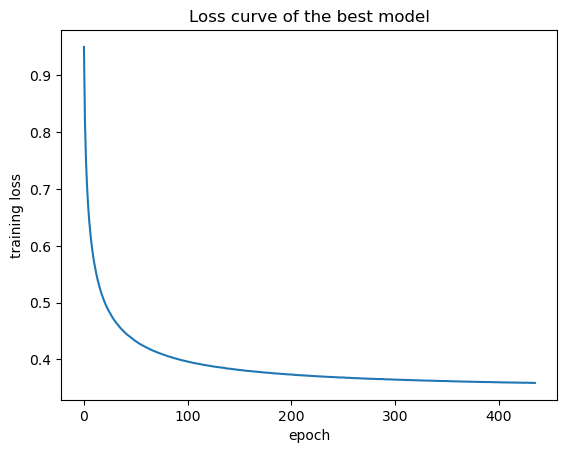

In [8]:
# final evaluation of the best model on the held-out TEST set
best_model = best["model"]
y_hat = best_model.predict(X_test_np)
print(best_model.report(y_test, y_hat))

plt.plot(best_model.loss_history)
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("Loss curve of the best model")
plt.show()

### 3.3 Final evaluation of the best model (test set)

| Class | Name | Precision | Recall | F1 | Support |
|---|---|---|---|---|---|
| 0 | Budget | 0.79 | 0.65 | 0.71 | 110 |
| 1 | Affordable | 0.86 | 0.86 | 0.86 | 852 |
| 2 | Premium | 0.82 | 0.86 | 0.84 | 577 |
| 3 | Luxury | 0.94 | 0.96 | 0.95 | 67 |
| | **accuracy** | | | **0.85** | 1606 |
| | macro avg | 0.85 | 0.83 | 0.84 | 1606 |
| | weighted avg | 0.85 | 0.85 | 0.85 | 1606 |

**Which classes are hardest?**

- **Budget (class 0) is the hardest**, with recall of only 0.65. It is rare (6.9% of the data) and its price band sits right next to Affordable, so errors flow one class upward. The confusion matrix below confirms it: all 39 misclassified Budget cars were predicted as Affordable.
- **Luxury (class 3) is the easiest** even though it is the rarest: 64 of its 67 test cars are classified correctly. High `max_power` and recent `year` plausibly make these cars distinctive.
- **Class imbalance.** Weighted F1 (0.85) is slightly above macro F1 (0.84): the model does a little better on the classes that dominate the data. In production I would consider class weights or resampling for the Budget class.


                 pred Budget  pred Affordable  pred Premium  pred Luxury
true Budget               71               39             0            0
true Affordable           19              730           103            0
true Premium               0               76           497            4
true Luxury                0                0             3           64


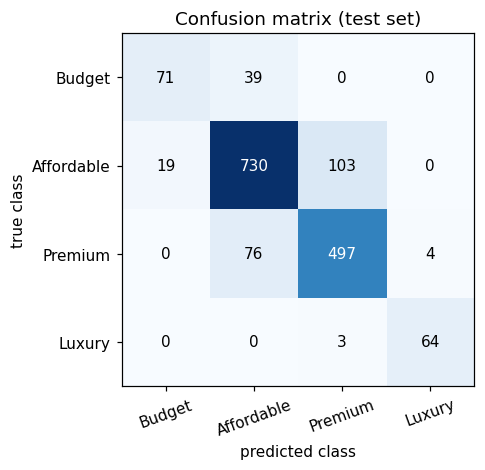

misclassified: 244 of 1606 | of which only one band away: 244


In [9]:
# confusion matrix of the best model on the TEST set (rows = true class, columns = predicted class)
cm = np.zeros((4, 4), dtype=int)
np.add.at(cm, (y_test, y_hat), 1)                 # count every (true, predicted) pair
names = ["Budget", "Affordable", "Premium", "Luxury"]
print(pd.DataFrame(cm, index=[f"true {n}" for n in names], columns=[f"pred {n}" for n in names]))

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_xticklabels(names, rotation=20)
ax.set_yticks(range(4)); ax.set_yticklabels(names)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("predicted class"); ax.set_ylabel("true class"); ax.set_title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()

# how far off are the mistakes? |true - predicted| = 1 means "the neighbouring price band"
wrong = y_test != y_hat
print("misclassified:", wrong.sum(), "of", len(y_test),
      "| of which only one band away:", (np.abs(y_test - y_hat)[wrong] == 1).sum())

### 3.4 Reading the confusion matrix

Rows are the true class and columns the predicted class, so the diagonal holds the correct predictions (1,362 of 1,606 = 84.8%).

- **Every one of the 244 mistakes lands in the neighbouring price band** (the last line printed by the code cell checks this). No car is ever wrong by two or three bands, which is a desirable property for an *ordered* target.
- **Budget:** 71 of 110 are correct and all 39 mistakes are predicted as Affordable. This is why Budget has the lowest recall.
- **Affordable and Premium**, the two largest classes, account for most of the remaining errors: 103 Affordable cars are predicted as Premium and 76 Premium cars as Affordable.
- **Luxury:** 64 of 67 are correct; the 3 mistakes are predicted as Premium.


### 3.5 Loss curve

The plot in the code cell above (before §3.3) shows the training loss of the best model. It falls steeply in the first ~50 epochs and then flattens smoothly, with no oscillation or divergence. This is consistent with the moderate learning rate ($\alpha = 0.1$) combined with mini-batch updates. The curve ends at epoch 436 rather than at `max_iter = 500` because the class stops early once the loss changes by less than `tol = 1e-7` between two epochs.


## Task 3, Objective 2: Model registry

Following the TA's announcement, the registry was run locally and the screenshots below are the evidence for Objectives 1 and 2.

### 4.1 Experiment runs

![MLflow runs list for experiment st126736-a3](docs/mlflow_runs.png)

**Figure 1.** MLflow runs list for experiment `st126736-a3`, sorted by validation weighted F1. The sweep has 16 configurations (one per method, $\alpha$ and penalty). The notebook was executed four times, so each configuration appears four times (64 runs in total) with identical metrics. Best configuration: `minibatch-lr0.1-noPenalty`.

### 4.2 Registered best model

The best run was registered as **`st126736-a3-model`**, Version 1, with the alias **`staging`**. MLflow 3.x deprecates the classic "Stage" dropdown (the screenshot shows *Stage (deprecated): None*); the alias is the supported equivalent of putting the model at staging.

![Registered model st126736-a3-model, version 1](docs/mlflow_registered.png)

**Figure 2.** Model registry: `st126736-a3-model`, Version 1, alias `@staging`, source run `minibatch-lr0.1-noPenalty`.

### 4.3 How the registration was done

1. Start the local UI: `python -m mlflow ui --backend-store-uri sqlite:///mlflow.db` and open `http://127.0.0.1:5000`.
2. Open experiment `st126736-a3`, then the best run (`minibatch-lr0.1-noPenalty`) → **Artifacts** → `model/` → **Register model** → create a new model named `st126736-a3-model`.
3. Open **Model registry** → `st126736-a3-model` → **Version 1** and set the alias to `staging`.

## 5. Deployment

### 5.1 Flask web app

The app lives in `app/`. At start-up it loads `app/Model/model.pkl` (the best model) and `app/Model/preprocess.pkl` (feature column order, scaler mean and scale, brand and fuel lists, class price edges). For each request it:

1. reads brand, fuel, year, max power and mileage from the form,
2. rebuilds the 35-feature vector in the **exact column order used in training** (one-hot brand and fuel),
3. standardises the numeric columns with the saved scaler,
4. calls `LogisticRegression.predict` and shows the predicted class, its price range, and all four ranges with the predicted one highlighted.

The app predicts a **price range, not an exact price**, which matches the classification task.

Run locally:

```powershell
cd app
$env:PORT = 8050
python app.py
```

![Local Flask app prediction](docs/flask_local.png)

**Figure 3.** Local Flask app. Input: BMW, Diesel, 2010, 81 bhp, 57 kmpl. Prediction: **Affordable** (₹128,183 – ₹547,713).

### 5.2 Docker

The same app runs through Docker Compose at `http://localhost:8080`.

- `Dockerfile`: based on `python:3.10-slim`, installs `requirements.txt`, copies `app/` into the image, exposes port 80, runs `python app.py`.
- `docker-compose.yaml`: maps host port 8080 to container port 80 (local run).
- `docker-compose-bridge.yaml` and `docker-compose-deploy.yaml` are used on the course VM, see §5.3.

![Docker deployment on localhost:8080](docs/docker_localhost.png)

**Figure 4.** The app running from the Docker container at `http://localhost:8080`.

### 5.3 Running on the course VM

The GitHub Actions pipeline (§6.2) builds the image, pushes it to Docker Hub as `jarin19/car-price-app-a3:latest`, connects over SSH to the course VM `ml.brain.cs.ait.ac.th` through the jump host `bazooka.cs.ait.ac.th`, copies the compose file to `~/a3` and starts the container there. Two compose files are in the repository:

| File | Setup | Status |
|---|---|---|
| `docker-compose-deploy.yaml` | Traefik labels, hostname `st126736.ml.brain.cs.ait.ac.th`, external `traefik_default` network (the course's standard setup, as used in A2) | **Not usable at the moment.** Starting the container fails with `failed to set up container networking: invalid cluster node while attaching to network`. `docker info` on the VM reports `Swarm: error` because the swarm certificate expired in November 2024, which I cannot renew without admin rights. |
| `docker-compose-bridge.yaml` | Docker's default bridge network, published port **8126** (`8126:80`), no Traefik | **Used by the pipeline.** The container starts and serves the app. |

Figure 5 shows the container running on the VM. The page was opened through an SSH tunnel (`localhost:8126`).

![App served from the Docker container on the course VM](docs/deployed_app.png)

**Figure 5.** The Flask app running in the Docker container on the course VM (port 8126). Input: Ambassador, Petrol, 2026, 80 bhp, 20 kmpl → **Luxury**. The year 2026 is outside the training data (1983 to 2020), so this input only demonstrates that the deployed container answers requests; it is not a meaningful price estimate.


## 6. Unit tests and CI/CD (Objective 3)

**GitHub repository:** https://github.com/J-Rodoshi/A3-Predicting-Car-Price

All code, the Jupyter notebook, the Docker setup and the CI/CD pipeline live in the repository above under the GitHub account **`J-Rodoshi`**.

### 6.1 Unit tests

Two unit tests in `app/tests/test_model.py` cover the two requirements of the assignment:

| Test | What it checks |
|---|---|
| `test_model_takes_expected_input` | A model trained on a small synthetic dataset (6 features) accepts a feature matrix of the expected width and raises `ValueError` when the width is wrong. |
| `test_output_has_expected_shape` | For 5 input rows the predictions have shape `(5,)` with labels in {0, 1, 2, 3}, and the probability output has shape `(5, 4)` with every row summing to 1. |

The tests build their own tiny model from synthetic data, so they need no CSV, no saved model file, no MLflow server and no network access, and they run cleanly inside the CI runner.

Run from the repository root:

```powershell
$env:PYTHONPATH = "app"
python -m pytest app/tests -v
```

Result:

```
app/tests/test_model.py::test_model_takes_expected_input PASSED   [ 50%]
app/tests/test_model.py::test_output_has_expected_shape  PASSED   [100%]
2 passed in 0.21s
```

### 6.2 GitHub Actions workflow

The workflow is committed at **`.github/workflows/ci-cd.yml`** in the repository `J-Rodoshi/A3-Predicting-Car-Price`. It runs on every push to `main` and on every pull request.

1. **Continuous integration: `test` job.** Checks out the repository, sets up Python 3.10, installs `numpy` and `pytest`, and runs `pytest app/tests -v`. A failing test fails the job.

2. **Continuous delivery: `deploy` job.** Runs only when the `test` job has succeeded (`needs: test`) **and** the event is a push to `main` (`if: github.ref == 'refs/heads/main' && github.event_name == 'push'`). It then:
   1. logs in to Docker Hub and builds the image, pushing it as `jarin19/car-price-app-a3:latest`;
   2. opens an SSH connection to the course VM through the jump host, copies `docker-compose-bridge.yaml` to `~/a3` and runs `docker compose pull` followed by `docker compose up -d`.

   The credentials are GitHub Actions secrets (`DOCKERHUB_USERNAME`, `DOCKERHUB_TOKEN`, `SSH_HOST`, `SSH_USER`, `SSH_PRIVATE_KEY`), so no secret is stored in the repository.

Because the deploy job depends on the test job, a single failing unit test blocks the build and nothing is pushed or deployed. The workflow therefore implements the requirement *"deploy only if the tests pass"*.

![GitHub Actions run #5: test and deploy jobs passed](docs/ci_green.png)

**Figure 6.** GitHub Actions run #5 on `main` (commit `e075995`): the `test` and `deploy` jobs both passed.

**How the pipeline got to green.** Earlier runs failed in the deploy job (they are visible in the Actions history): first because the SSH secrets were not configured, then because of a truncated shell command. Run #4 already reached `docker compose up` on the VM and failed with the Docker networking error described in §5.3. Run #5 switched the deploy step to `docker-compose-bridge.yaml` and passed.

### 6.3 Repository

All deliverables for this assignment are in the GitHub repository under the account **`J-Rodoshi`**:

- Repository: https://github.com/J-Rodoshi/A3-Predicting-Car-Price
- Notebook: `A3_predicting_car_price.ipynb`
- Web application: `app/`
- Compose files: `docker-compose.yaml` (local), `docker-compose-bridge.yaml` (course VM), `docker-compose-deploy.yaml` (Traefik version)
- CI/CD workflow: `.github/workflows/ci-cd.yml`

## 7. Conclusion

A multinomial logistic regression written from scratch classifies used cars into four price ranges with **84.8% test accuracy and 0.847 weighted F1**. The custom metric functions match scikit-learn exactly, and the optional Ridge penalty works as designed (it shrinks the weights about 18 times at $\lambda = 0.1$).

The 16-run MLflow sweep showed that for this dataset **mini-batch gradient descent with $\alpha = 0.1$ and no regularisation** is best. Mini-batch beat batch in 7 of 8 matched settings, $\alpha = 0.1$ beat 0.01 in 7 of 8 pairs within a 500-iteration budget (the exceptions are all over-regularised $\lambda = 0.1$ runs where the two are essentially tied), and Ridge only hurt because the model has few features relative to the amount of data. The weakest class is Budget (recall 0.65), mainly because it is rare and borders the large Affordable class.

The best model was registered in MLflow as `st126736-a3-model` (alias `staging`), served through a Flask app packaged in Docker, covered by two unit tests, and wired into a GitHub Actions pipeline that tests every push and, on `main`, builds the image and deploys it to the course VM when the tests pass (run #5 is green, Figure 6). The course's Traefik setup could not be used because the VM's Docker Swarm certificate has expired, so the pipeline deploys with a published port (8126) on Docker's default network instead (§5.3).

**Possible improvements:** repeat runs over several seeds to put error bars on the comparison; train longer at $\alpha = 0.01$; tune $\lambda$ on a finer grid at or below 0.001; add class weights or resampling for the Budget class; try quantile-based price classes.

## Appendix: all 16 runs (experiment `st126736-a3`)

Sorted by validation weighted F1.

| Run | Val acc | Val macro F1 | Val weighted F1 | Test acc | Test macro F1 | Test weighted F1 | Final train loss |
|---|---|---|---|---|---|---|---|
| minibatch-lr0.1-noPenalty | 0.8436 | 0.8245 | 0.8418 | 0.8481 | 0.8402 | 0.8473 | 0.3587 |
| minibatch-lr0.1-ridge0.001 | 0.8366 | 0.7954 | 0.8325 | 0.8418 | 0.8157 | 0.8394 | 0.4407 |
| minibatch-lr0.01-noPenalty | 0.8163 | 0.7355 | 0.8094 | 0.8294 | 0.7869 | 0.8259 | 0.4330 |
| minibatch-lr0.01-ridge0.001 | 0.8125 | 0.7229 | 0.8039 | 0.8269 | 0.7820 | 0.8227 | 0.4686 |
| batch-lr0.1-ridge0.001 | 0.8109 | 0.6839 | 0.7981 | 0.8138 | 0.7396 | 0.8081 | 0.5102 |
| batch-lr0.1-noPenalty | 0.8101 | 0.6812 | 0.7975 | 0.8132 | 0.7379 | 0.8076 | 0.4894 |
| minibatch-lr0.1-ridge0.01 | 0.7899 | 0.5981 | 0.7720 | 0.7920 | 0.6541 | 0.7804 | 0.6185 |
| minibatch-lr0.01-ridge0.01 | 0.7875 | 0.5775 | 0.7682 | 0.7846 | 0.6020 | 0.7695 | 0.6197 |
| batch-lr0.1-ridge0.01 | 0.7798 | 0.5606 | 0.7590 | 0.7790 | 0.5897 | 0.7631 | 0.6272 |
| batch-lr0.01-noPenalty | 0.7447 | 0.3892 | 0.6997 | 0.7403 | 0.3902 | 0.6960 | 0.7872 |
| batch-lr0.01-ridge0.001 | 0.7447 | 0.3892 | 0.6997 | 0.7403 | 0.3902 | 0.6960 | 0.7895 |
| batch-lr0.01-ridge0.01 | 0.7393 | 0.3852 | 0.6936 | 0.7410 | 0.3856 | 0.6950 | 0.8090 |
| batch-lr0.01-ridge0.1 | 0.7160 | 0.3673 | 0.6660 | 0.7229 | 0.3714 | 0.6727 | 0.9216 |
| minibatch-lr0.1-ridge0.1 | 0.7167 | 0.3670 | 0.6656 | 0.7098 | 0.3621 | 0.6580 | 0.8525 |
| minibatch-lr0.01-ridge0.1 | 0.7160 | 0.3663 | 0.6646 | 0.7173 | 0.3672 | 0.6662 | 0.8525 |
| batch-lr0.1-ridge0.1 | 0.7152 | 0.3659 | 0.6639 | 0.7173 | 0.3673 | 0.6663 | 0.8524 |